In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr

In [2]:
results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0629_0934_test")

In [3]:
train_scenario_sum_df = pd.read_parquet(results_dir / "train_scenario_summary.parquet")

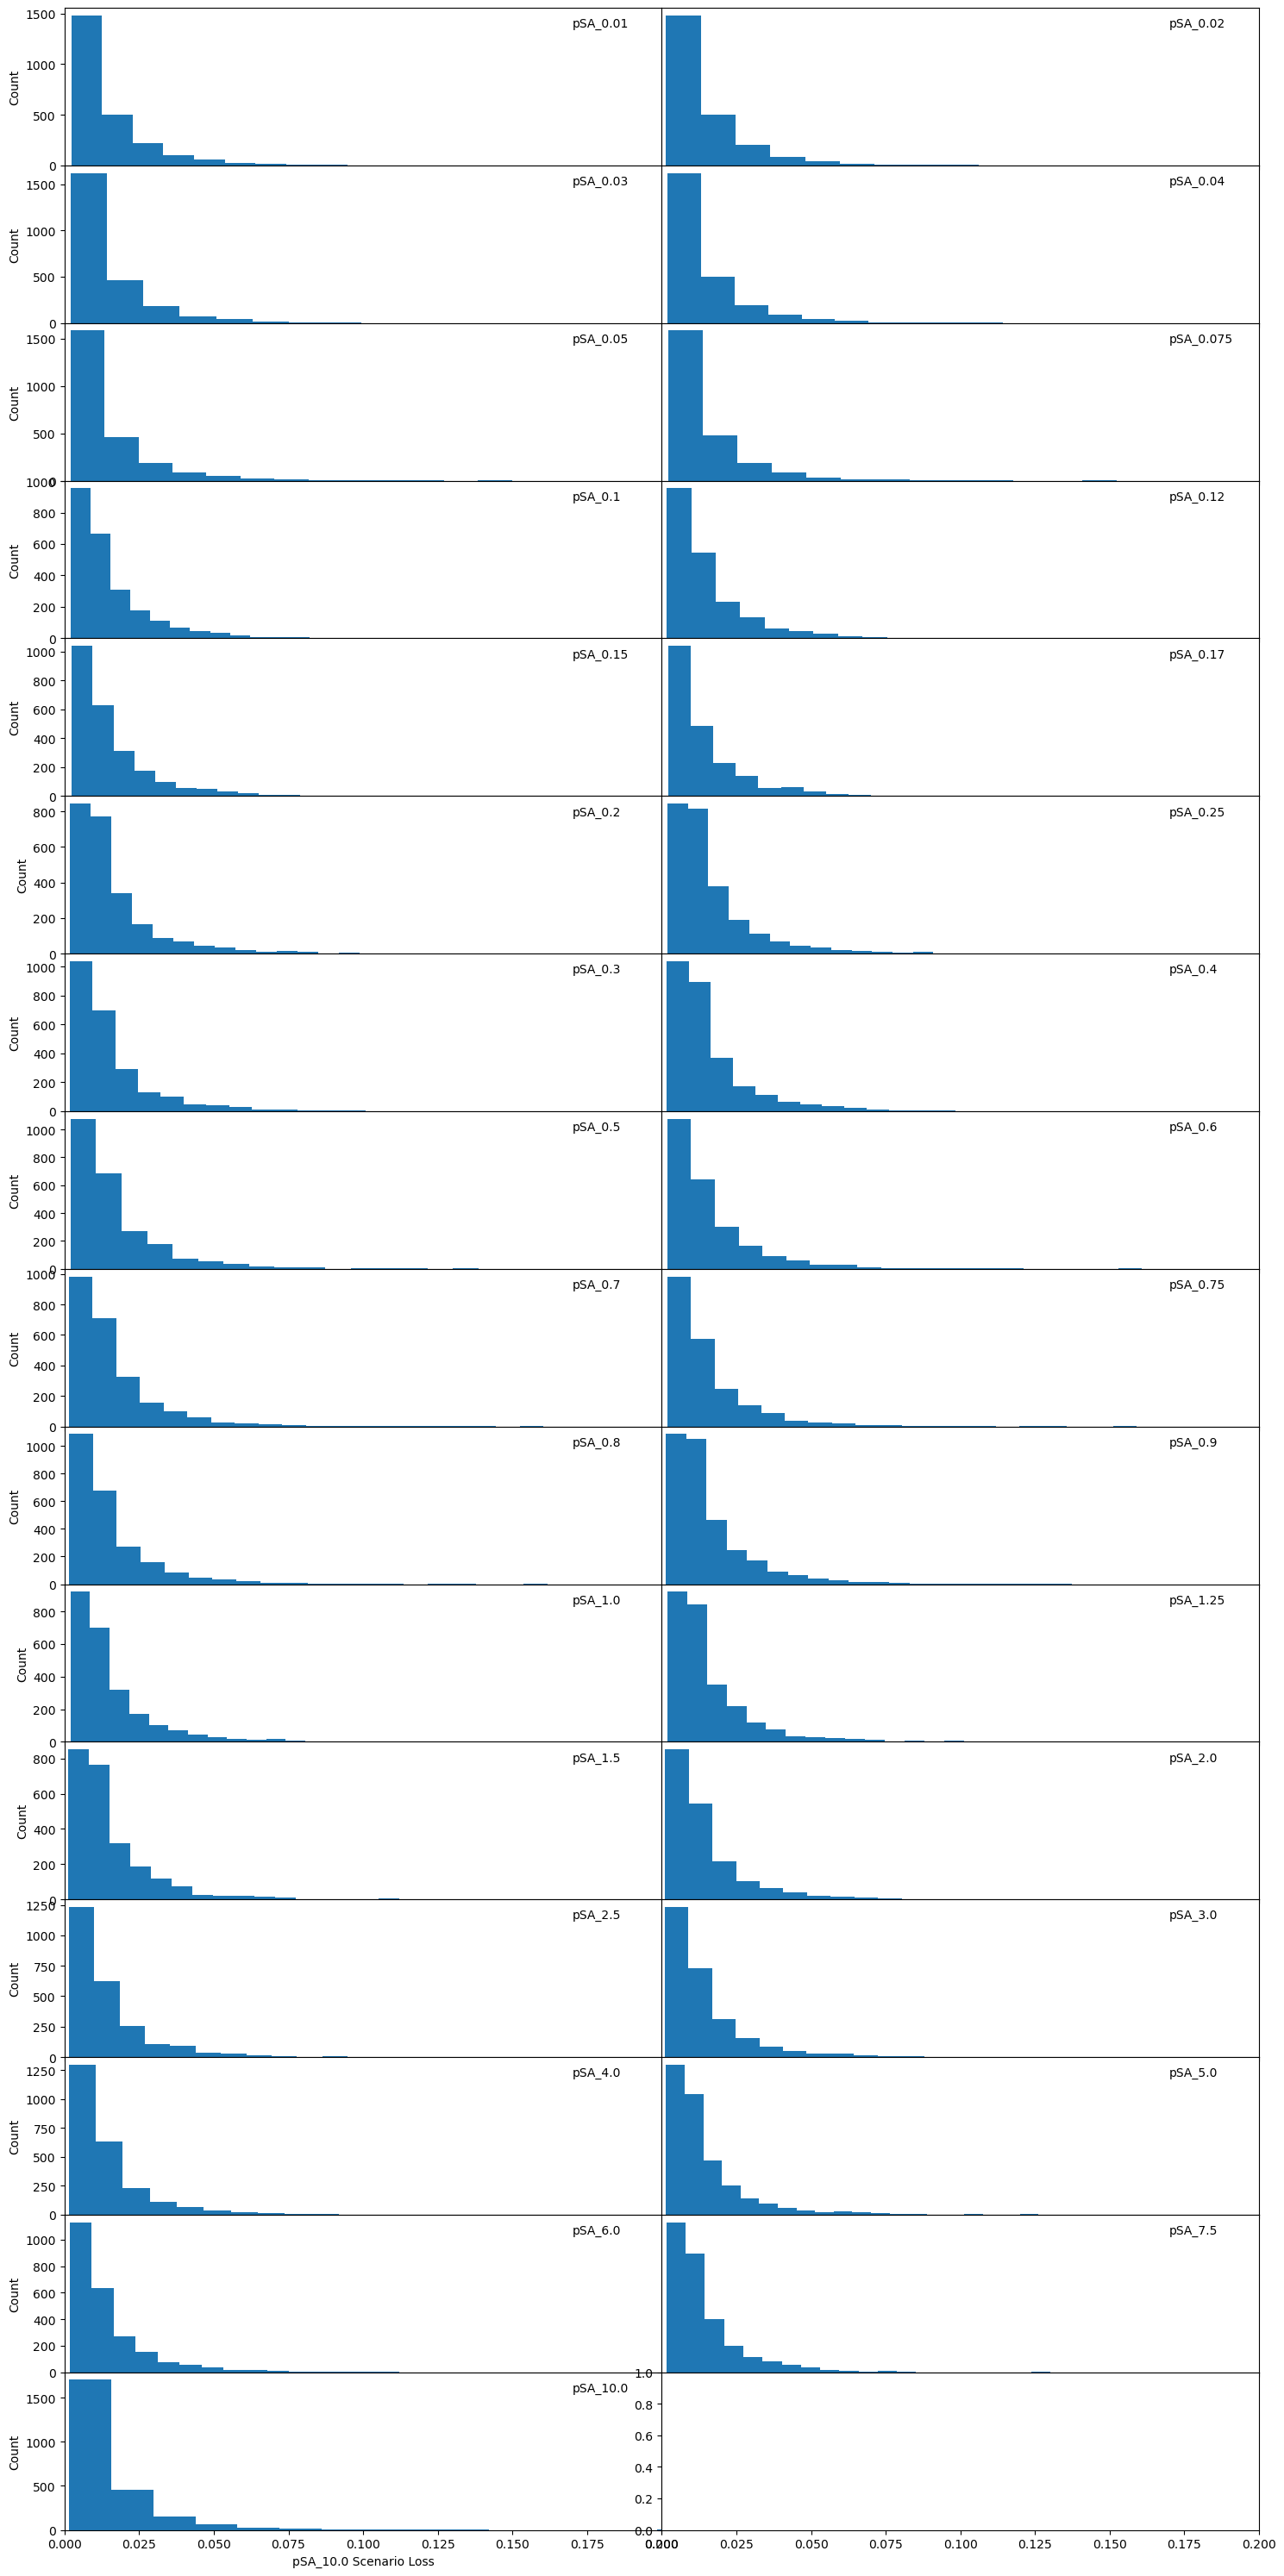

In [8]:
ims = sr.constants.PSA_KEYS
n_bins = 20

# Create subplots with shared x-axis
fig, axs = plt.subplots(int(np.ceil(len(ims) / 2)), 2, figsize=(15, 30), sharex=True)

axs = axs.flatten()

for i, im in enumerate(ims):
    ax = axs[i]
    ax.hist(train_scenario_sum_df[f"{im}_scenario_loss"], bins=n_bins)
    ax.set_xlim(0, 0.2)
    ax.set_xlabel("{} Scenario Loss".format(im) if i >= len(ims) - 2 else "")
    ax.set_ylabel("Count" if i % 2 == 0 else "")
    ax.text(0.85, 0.9, f"{im}", horizontalalignment="left", verticalalignment="center", transform=ax.transAxes)
    
    if i % 2 != 0:  # For the second column, remove y-ticks
        ax.set_yticks([])
        ax.set_yticklabels([])
        
fig.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0)

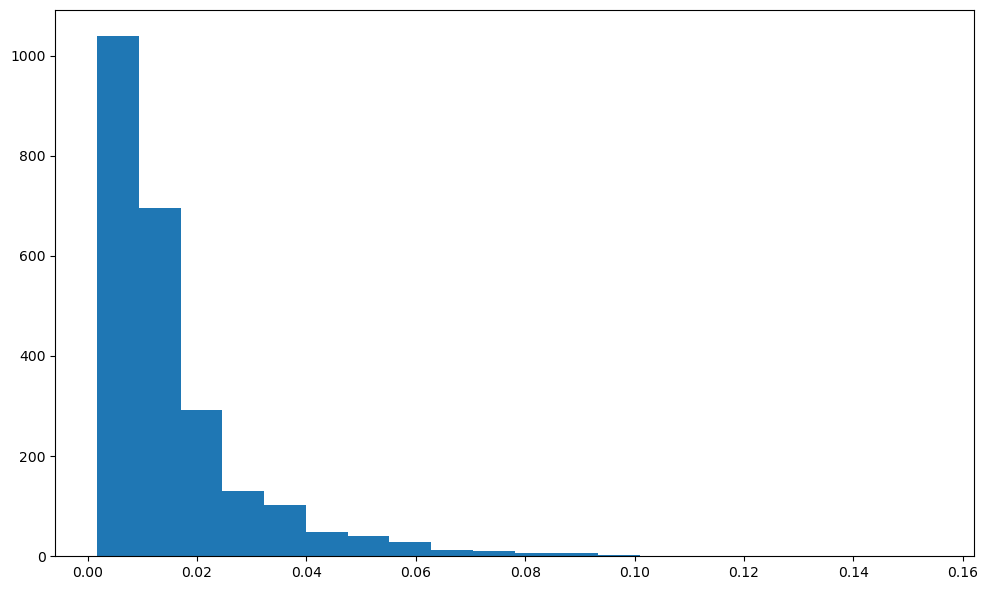

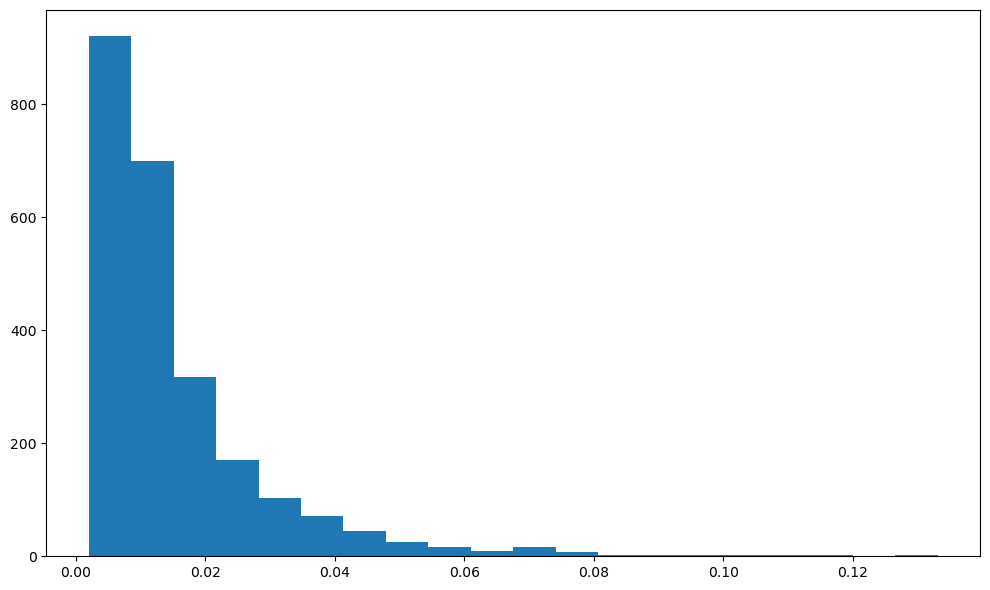

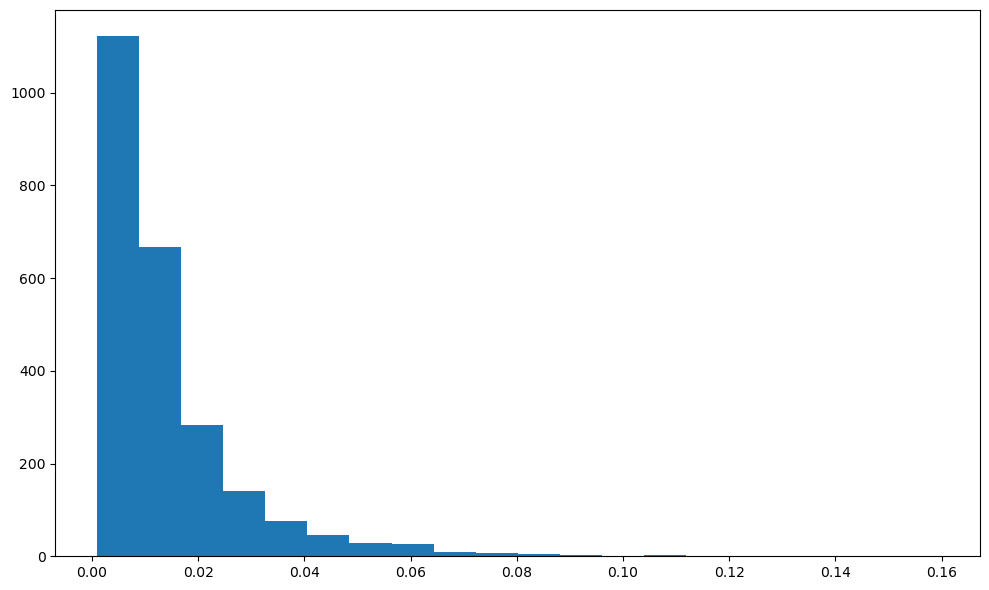

In [10]:
ims = ["pSA_0.3", "pSA_1.0", "pSA_3.0"]

for cur_im in ims:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(train_scenario_sum_df[f"{cur_im}_scenario_loss"], bins=n_bins)
    
    fig.tight_layout()